In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np

# Fix path so Python can find your new src/model_trainer.py
if '..' not in sys.path:
    sys.path.append('..')

from src.model_trainer import ModelTrainer

trainer     = ModelTrainer('../data/processed/features_dataset.parquet')
results_df  = trainer.cross_validate_all()

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

Dataset loaded: 2333 windows, 23 features, 4 classes

Running 5-fold cross-validation...
Model                  |   Acc Mean |  Acc Std |    F1 Mean |   F1 Std
──────────────────────────────────────────────────────────────────────
  Random Forest        |    0.9987  |  0.0017  |    0.9987  |  0.0018
  Gradient Boosting    |    0.9940  |  0.0034  |    0.9933  |  0.0040
  SVM (RBF)            |    0.9996  |  0.0009  |    0.9996  |  0.0009
  KNN                  |    0.9979  |  0.0014  |    0.9978  |  0.0014
  Decision Tree        |    0.9919  |  0.0032  |    0.9900  |  0.0041

CROSS-VALIDATION RESULTS SUMMARY
            Model  Acc_Mean  Acc_Std  F1_Mean  F1_Std  Acc_Min  Acc_Max
        SVM (RBF)    0.9996   0.0009   0.9996  0.0009   0.9979   1.0000
    Random Forest    0.9987   0.0017   0.9987  0.0018   0.9957   1.0000
              KNN    0.9979   0.0014   0.9978  0.0014   0.9957   1.0000
Gradient Boosting    0.9940   0.0034   0.9933  0.0040   0.9893   0.9979
    Decision Tree    0.99

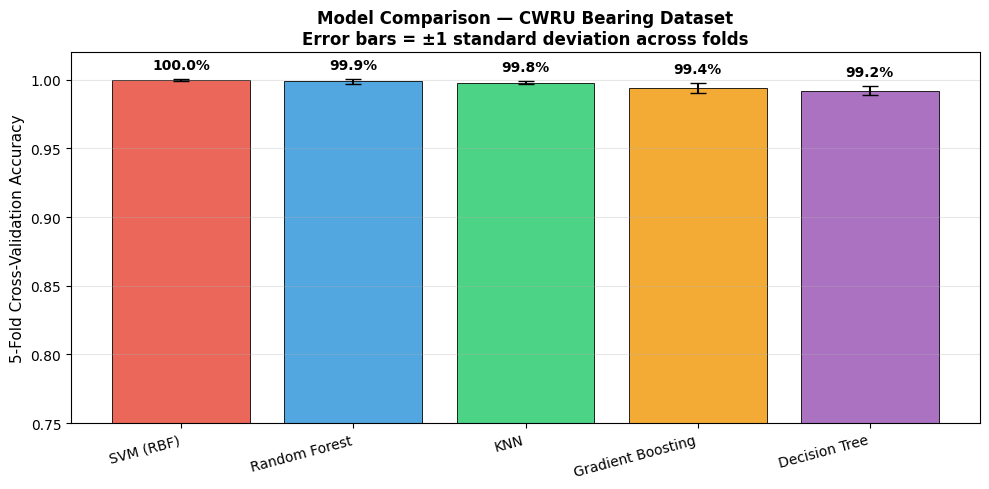

In [2]:
models   = results_df['Model'].tolist()
acc_mean = results_df['Acc_Mean'].tolist()
acc_std  = results_df['Acc_Std'].tolist()

COLORS_BAR = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    models, acc_mean,
    yerr       = acc_std,
    color      = COLORS_BAR,
    alpha      = 0.85,
    capsize    = 6,
    edgecolor  = 'black',
    linewidth  = 0.7,
    error_kw   = {'linewidth': 1.5}
)

# Label each bar with accuracy
for bar, val, std in zip(bars, acc_mean, acc_std):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + std + 0.005,
        f'{val:.1%}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_ylim(0.75, 1.02)
ax.set_ylabel('5-Fold Cross-Validation Accuracy', fontsize=11)
ax.set_title(
    'Model Comparison — CWRU Bearing Dataset\n'
    'Error bars = ±1 standard deviation across folds',
    fontsize=12, fontweight='bold'
)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/day7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Dataset loaded: 2333 windows, 23 features, 4 classes

Training final Random Forest model...
  Train set: 1866 windows
  Test set:  467 windows

Final Test Accuracy: 1.0000 (100.0%)

Per-class performance:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       165
  Inner Race     1.0000    1.0000    1.0000       139
  Outer Race     1.0000    1.0000    1.0000        70
Ball Element     1.0000    1.0000    1.0000        93

    accuracy                         1.0000       467
   macro avg     1.0000    1.0000    1.0000       467
weighted avg     1.0000    1.0000    1.0000       467


Model saved to models/final_model.pkl
Scaler saved to models/scaler.pkl


FileNotFoundError: [Errno 2] No such file or directory: 'reports\\figures\\day8_confusion_matrix.png'

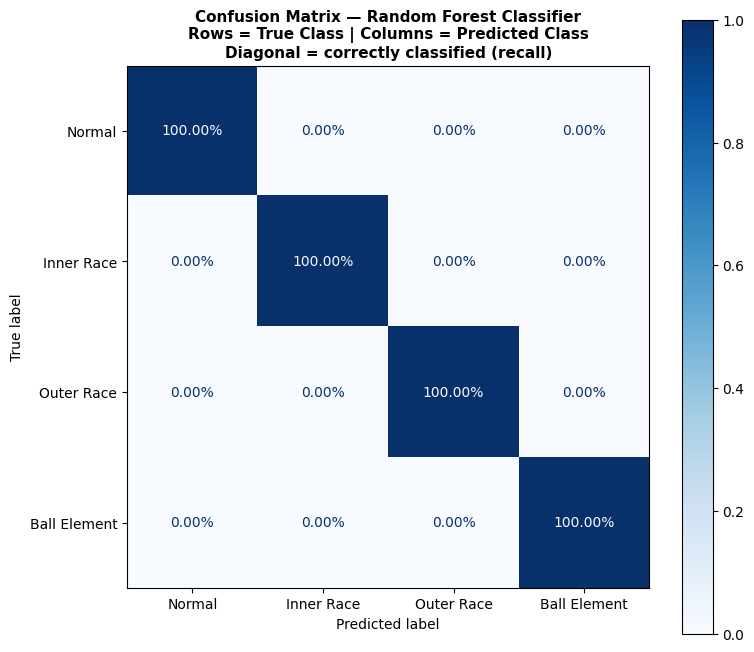

In [1]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

from src.model_evaluator import ModelEvaluator
from src.model_trainer   import ModelTrainer

# Load trainer to get scaled data
trainer   = ModelTrainer('../data/processed/features_dataset.parquet')
evaluator = ModelEvaluator()

# Re-run final model to get test predictions (this is fast)
model, scaler, X_test, y_test, y_pred = trainer.train_final_model(
    model_name='Random Forest'
)

# Plot the Confusion matrix
evaluator.plot_confusion_matrix(y_test, y_pred, normalize=True)

Dataset loaded: 2333 windows, 23 features, 4 classes


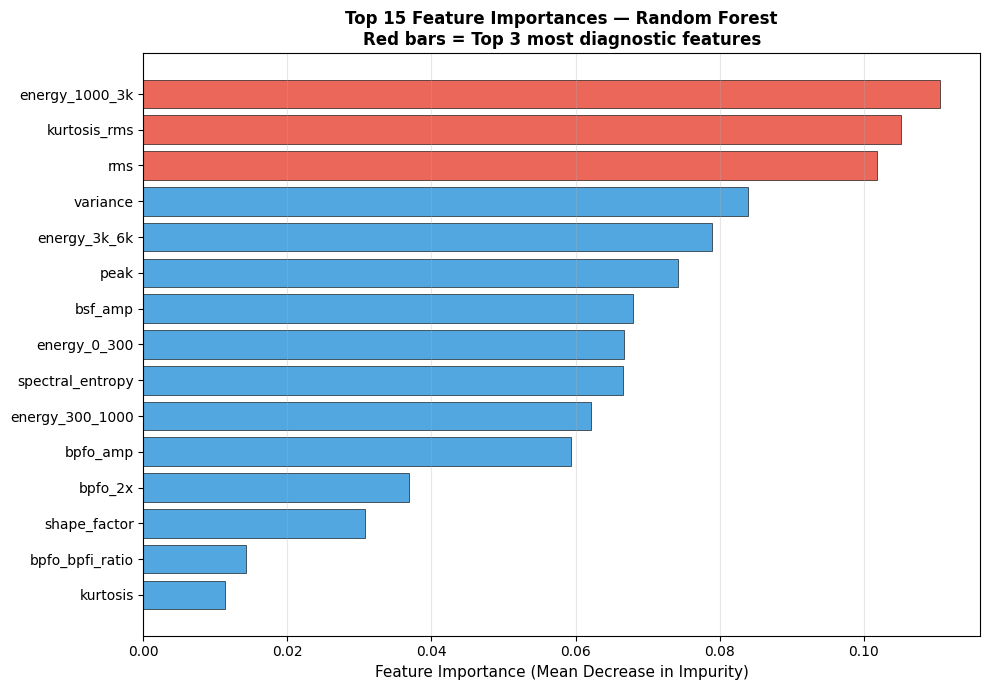


Top 5 most important features:
  1. energy_1000_3k        : 0.1106 (11.1%)
  2. kurtosis_rms          : 0.1053 (10.5%)
  3. rms                   : 0.1018 (10.2%)
  4. variance              : 0.0840 (8.4%)
  5. energy_3k_6k          : 0.0790 (7.9%)


In [3]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

from src.model_evaluator import ModelEvaluator
from src.model_trainer   import ModelTrainer

# 1. Define the trainer and evaluator FIRST so Jupyter knows what they are
trainer   = ModelTrainer('../data/processed/features_dataset.parquet')
evaluator = ModelEvaluator()

# 2. NOW run the feature importance plot
evaluator.plot_feature_importance(
    feature_names = trainer.get_feature_names(),
    top_n         = 15
)

Computing learning curve (this takes ~1-2 minutes)...


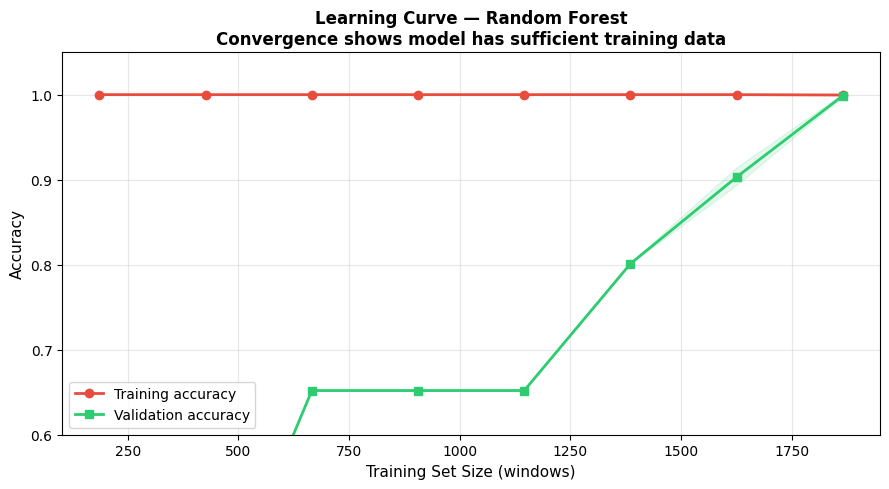


Final training accuracy:   0.9996
Final validation accuracy: 0.9987
Generalization gap:        0.0009
→ Minimal overfitting ✅


In [4]:
evaluator.plot_learning_curve(trainer.X_scaled, trainer.y)

In [6]:
import sys
import pandas as pd
from sklearn.metrics import classification_report

# Fix path
if '..' not in sys.path:
    sys.path.append('..')

from src.model_trainer import ModelTrainer

# 1. Reload the trainer and generate the test data and predictions
trainer = ModelTrainer('../data/processed/features_dataset.parquet')
model, scaler, X_test, y_test, y_pred = trainer.train_final_model(model_name='Random Forest')

# 2. NOW generate the classification report
report = classification_report(
    y_test, y_pred,
    target_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball'],
    output_dict  = True
)

report_df = pd.DataFrame(report).T.round(4)

print("\nPer-Class Performance Report:")
print(report_df.to_string())

print("\n\nHow to interpret this table:")
print("  precision: of all windows I called 'X', what fraction were truly 'X'?")
print("  recall:    of all truly 'X' windows, what fraction did I catch?")
print("  f1-score:  harmonic mean of precision and recall")

print("\n  For fault detection: RECALL is more important.")
print("  A missed fault (low recall) is worse than a false alarm (low precision).")

print(f"\n  Most difficult class to detect:")
worst = report_df.loc[['Normal','Inner Race','Outer Race','Ball'], 'recall'].idxmin()
print(f"  → {worst} has the lowest recall")

Dataset loaded: 2333 windows, 23 features, 4 classes

Training final Random Forest model...
  Train set: 1866 windows
  Test set:  467 windows

Final Test Accuracy: 1.0000 (100.0%)

Per-class performance:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       165
  Inner Race     1.0000    1.0000    1.0000       139
  Outer Race     1.0000    1.0000    1.0000        70
Ball Element     1.0000    1.0000    1.0000        93

    accuracy                         1.0000       467
   macro avg     1.0000    1.0000    1.0000       467
weighted avg     1.0000    1.0000    1.0000       467


Model saved to models/final_model.pkl
Scaler saved to models/scaler.pkl

Per-Class Performance Report:
              precision  recall  f1-score  support
Normal              1.0     1.0       1.0    165.0
Inner Race          1.0     1.0       1.0    139.0
Outer Race          1.0     1.0       1.0     70.0
Ball                1.0     1.0       1.0     93.0
a